In [1]:
import pandas as pd

df = pd.read_csv("students.csv")
# df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']

# ── 1. First 5 rows ───────────────────────────────────────────
print("=" * 50)
print("1. FIRST 5 ROWS")
print("=" * 50)
print(df.head())

# ── 2. Shape and data types ───────────────────────────────────
print("\n" + "=" * 50)
print("2. SHAPE AND DATA TYPES")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nData types:")
print(df.dtypes)

# ── 3. Summary statistics ─────────────────────────────────────
print("\n" + "=" * 50)
print("3. SUMMARY STATISTICS (numeric columns)")
print("=" * 50)
print(df.describe().round(2))

# ── 4. Pass / Fail count ──────────────────────────────────────
print("\n" + "=" * 50)
print("4. PASS / FAIL COUNT")
print("=" * 50)
counts = df['passed'].value_counts()
print(f"Passed : {counts[1]} students")
print(f"Failed : {counts[0]} students")

# ── 5. Average score per subject (passed vs failed) ───────────
print("\n" + "=" * 50)
print("5. AVERAGE SCORE PER SUBJECT")
print("=" * 50)
avg_passed = df[df['passed'] == 1][subject_cols].mean().round(2)
avg_failed = df[df['passed'] == 0][subject_cols].mean().round(2)

comparison = pd.DataFrame({
    'Passed Avg': avg_passed,
    'Failed Avg': avg_failed,
    'Difference': (avg_passed - avg_failed).round(2)
})
print(comparison)

# ── 6. Student with highest overall average ───────────────────
print("\n" + "=" * 50)
print("6. TOP STUDENT (highest overall average)")
print("=" * 50)
df['overall_avg'] = df[subject_cols].mean(axis=1).round(2)
top_student = df.loc[df['overall_avg'].idxmax()]
print(f"Name    : {top_student['name']}")
print(f"Average : {top_student['overall_avg']}")
print(f"Scores  : Math={top_student['math']}, Science={top_student['science']}, "
      f"English={top_student['english']}, History={top_student['history']}, PE={top_student['pe']}")

1. FIRST 5 ROWS
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

2. SHAPE AND DATA TYPES
Shape: 15 rows × 9 columns

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

3. SUMMARY STATISTICS (n

In [2]:
import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

print("✅ avg_score column added")
print(df[['name', 'avg_score']].head())

✅ avg_score column added
      name  avg_score
0    Alice       86.2
1      Bob       51.0
2  Charlie       76.2
3    Diana       94.0
4      Eve       46.0


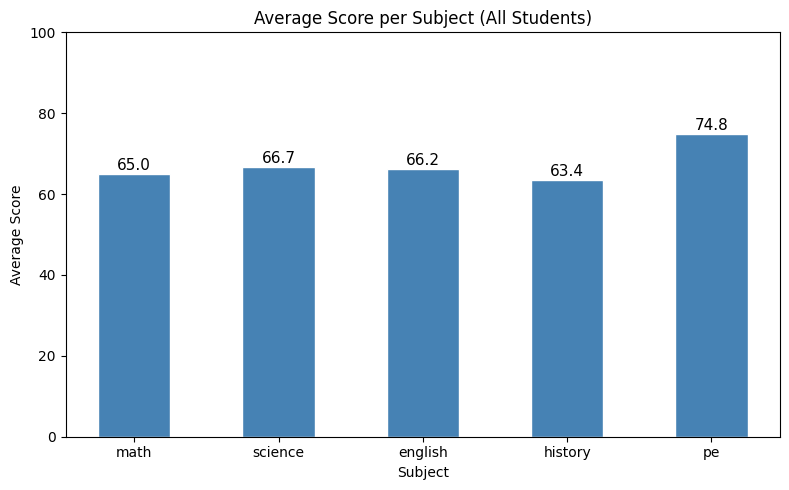

✅ plot1_bar.png saved


In [3]:
# ── Plot 1: Average score per subject ────────────────────────
subject_means = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_means.index, subject_means.values, color='steelblue', edgecolor='white', width=0.5)

plt.title('Average Score per Subject (All Students)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)

# Add value labels on top of each bar
for i, val in enumerate(subject_means.values):
    plt.text(i, val + 1, f'{val:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('plot1_bar.png')
plt.show()
print("✅ plot1_bar.png saved")

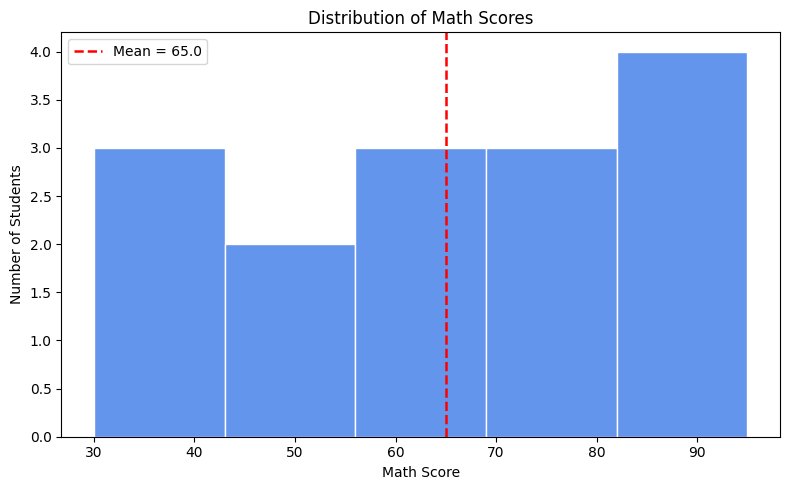

✅ plot2_histogram.png saved


In [4]:
# ── Plot 2: Distribution of math scores ──────────────────────
math_mean = df['math'].mean()

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='cornflowerblue', edgecolor='white')

# Vertical dashed line at mean
plt.axvline(math_mean, color='red', linestyle='--', linewidth=1.8, label=f'Mean = {math_mean:.1f}')

plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.legend()

plt.tight_layout()
plt.savefig('plot2_histogram.png')
plt.show()
print("✅ plot2_histogram.png saved")

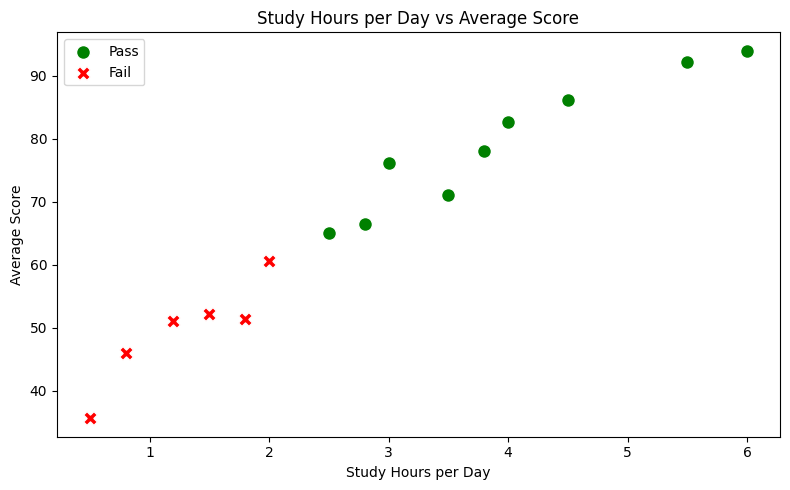

✅ plot3_scatter.png saved


In [5]:
# ── Plot 3: Study hours vs avg_score (coloured by passed) ────
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(passed['study_hours_per_day'], passed['avg_score'],
            color='green', marker='o', s=100, label='Pass', edgecolors='white')
plt.scatter(failed['study_hours_per_day'], failed['avg_score'],
            color='red', marker='X', s=100, label='Fail', edgecolors='white')

plt.title('Study Hours per Day vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()

plt.tight_layout()
plt.savefig('plot3_scatter.png')
plt.show()
print("✅ plot3_scatter.png saved")

C:\Users\ashwi\AppData\Local\Temp\ipykernel_9616\3311704159.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance],


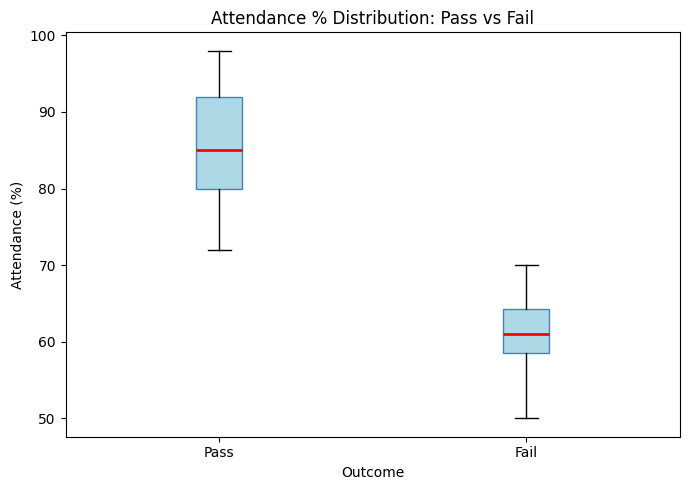

✅ plot4_boxplot.png saved


In [6]:
# ── Plot 4: Attendance distribution — Pass vs Fail ───────────
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(7, 5))
plt.boxplot([pass_attendance, fail_attendance],
            labels=['Pass', 'Fail'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='steelblue'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Attendance % Distribution: Pass vs Fail')
plt.xlabel('Outcome')
plt.ylabel('Attendance (%)')

plt.tight_layout()
plt.savefig('plot4_boxplot.png')
plt.show()
print("✅ plot4_boxplot.png saved")

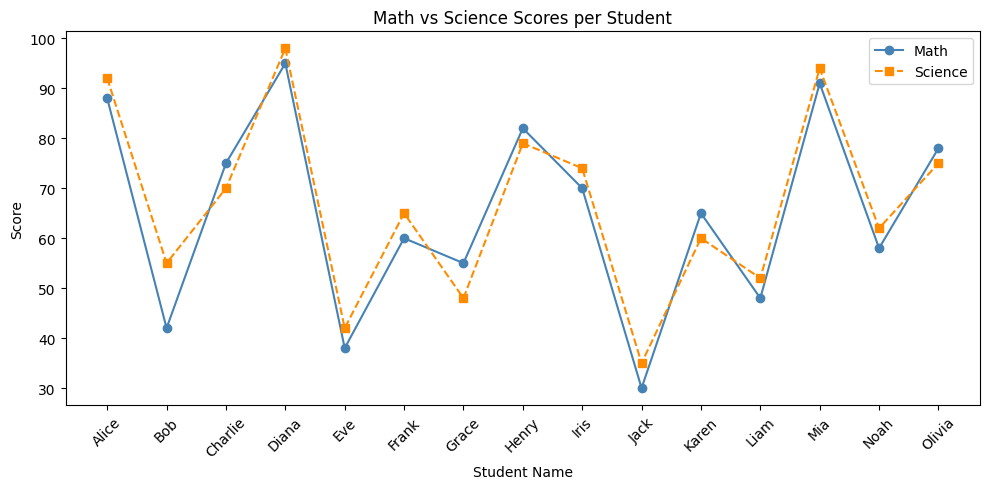

✅ plot5_line.png saved


In [7]:
# ── Plot 5: Math and Science scores per student ───────────────
names = df['name']

plt.figure(figsize=(10, 5))
plt.plot(names, df['math'],    marker='o', linestyle='-',  color='steelblue', label='Math')
plt.plot(names, df['science'], marker='s', linestyle='--', color='darkorange', label='Science')

plt.title('Math vs Science Scores per Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('plot5_line.png')
plt.show()
print("✅ plot5_line.png saved")

C:\Users\ashwi\AppData\Local\Temp\ipykernel_9616\1057597876.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette=['#e74c3c', '#2ecc71'])
C:\Users\ashwi\AppData\Local\Temp\ipykernel_9616\1057597876.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette=['#e74c3c', '#2ecc71'])
C:\Users\ashwi\AppData\Local\Temp\ipykernel_9616\1057597876.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Fail', 'Pass'])


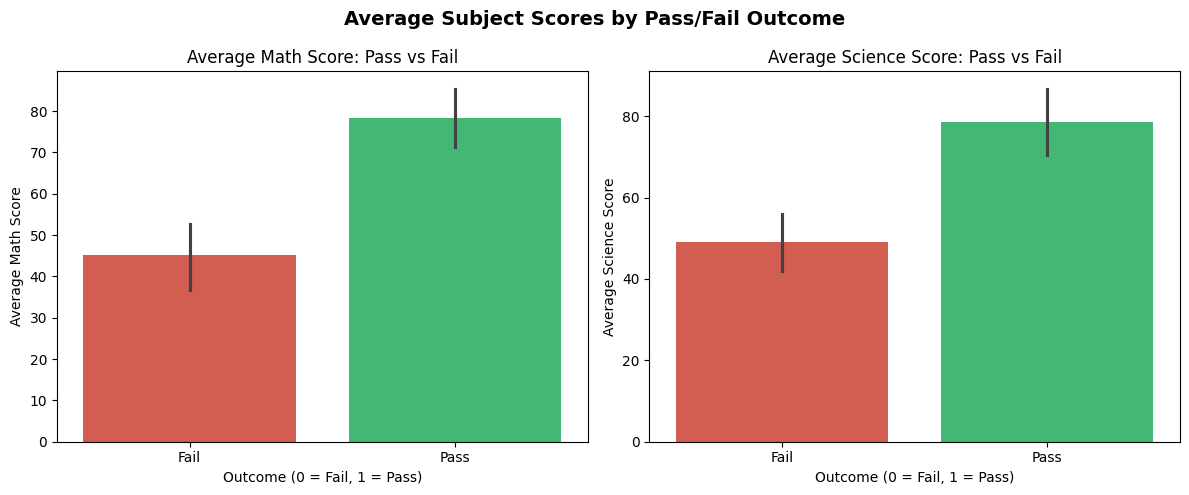

✅ plot6_seaborn_bar.png saved


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Seaborn Bar Plot: Math and Science avg split by passed ────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot — Math
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette=['#e74c3c', '#2ecc71'])
ax1.set_title('Average Math Score: Pass vs Fail')
ax1.set_xlabel('Outcome (0 = Fail, 1 = Pass)')
ax1.set_ylabel('Average Math Score')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Fail', 'Pass'])

# Right subplot — Science
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette=['#e74c3c', '#2ecc71'])
ax2.set_title('Average Science Score: Pass vs Fail')
ax2.set_xlabel('Outcome (0 = Fail, 1 = Pass)')
ax2.set_ylabel('Average Science Score')
ax2.set_xticklabels(['Fail', 'Pass'])

fig.suptitle('Average Subject Scores by Pass/Fail Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png')
plt.show()
print("✅ plot6_seaborn_bar.png saved")

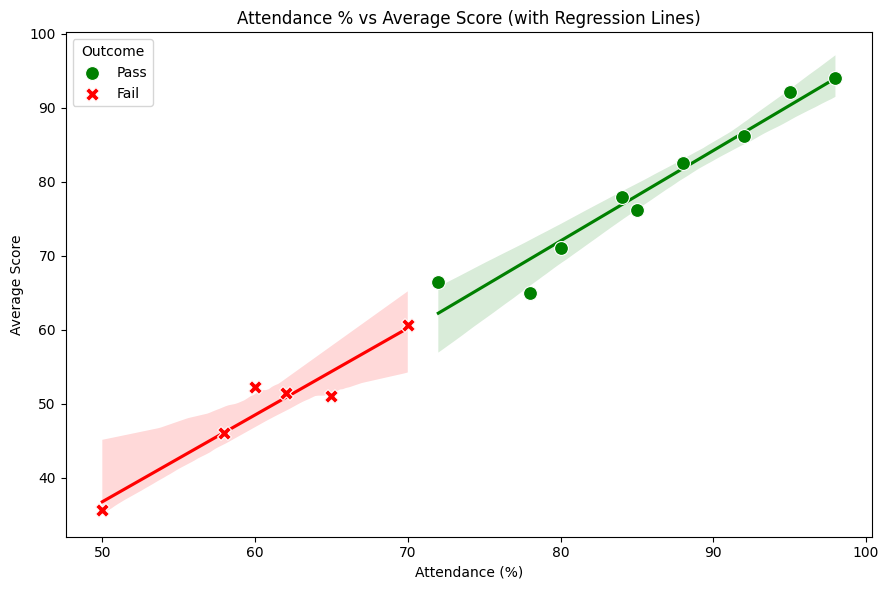

✅ plot7_seaborn_scatter_reg.png saved


In [9]:
# ── Seaborn Scatter + Regression: Attendance vs avg_score ─────
plt.figure(figsize=(9, 6))

# Scatter points coloured by group
sns.scatterplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
                color='green', marker='o', s=100, label='Pass', zorder=3)
sns.scatterplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
                color='red', marker='X', s=100, label='Fail', zorder=3)

# Regression lines per group
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            scatter=False, color='green', label='_nolegend_')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            scatter=False, color='red', label='_nolegend_')

plt.title('Attendance % vs Average Score (with Regression Lines)')
plt.xlabel('Attendance (%)')
plt.ylabel('Average Score')
plt.legend(title='Outcome')

plt.tight_layout()
plt.savefig('plot7_seaborn_scatter_reg.png')
plt.show()
print("✅ plot7_seaborn_scatter_reg.png saved")

# ── Seaborn vs Matplotlib — Reflection ───────────────────────
# Seaborn required far less code for polished results — sns.barplot() automatically
# computed group averages and added error bars without any manual calculation.
# Matplotlib gave more low-level control (exact colours, bar positions, text labels),
# but required more lines to achieve the same visual quality.
# For quick statistical plots, Seaborn is clearly faster; for custom, fine-tuned
# visuals, Matplotlib is more flexible.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Separate features and target ──────────────────────────────
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]   # df stays intact — name column still in df
y = df['passed']

# ── Train / test split (80% / 20%) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale features ────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)       # transform only on test

print(f"Total students  : {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")
print(f"\nTest set indices: {list(X_test.index)}")
print(f"Test students   : {list(df.loc[X_test.index, 'name'])}")

Total students  : 15
Training samples: 12
Testing samples : 3

Test set indices: [9, 11, 0]
Test students   : ['Jack', 'Liam', 'Alice']


In [11]:
from sklearn.linear_model import LogisticRegression

# ── Train Logistic Regression ─────────────────────────────────
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# ── Training accuracy ─────────────────────────────────────────
train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_accuracy:.2%}")

Training Accuracy: 100.00%


In [12]:
from sklearn.metrics import accuracy_score

# ── Predict on test set ───────────────────────────────────────
y_pred = model.predict(X_test_scaled)

# ── Test accuracy ─────────────────────────────────────────────
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2%}")
print()

# ── Per-student prediction breakdown ─────────────────────────
print(f"{'Student':<10} {'Actual':<10} {'Predicted':<12} {'Result'}")
print("-" * 45)

test_names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(test_names, y_test, y_pred):
    actual_label    = 'Pass' if actual    == 1 else 'Fail'
    predicted_label = 'Pass' if predicted == 1 else 'Fail'
    result          = '✅ Correct' if actual == predicted else '❌ Wrong'
    print(f"{name:<10} {actual_label:<10} {predicted_label:<12} {result}")

Test Accuracy: 100.00%

Student    Actual     Predicted    Result
---------------------------------------------
Jack       Fail       Fail         ✅ Correct
Liam       Fail       Fail         ✅ Correct
Alice      Pass       Pass         ✅ Correct


Feature Coefficients (sorted by importance):
----------------------------------------
english                   +0.8125   → Push to Pass
attendance_pct            +0.5219   → Push to Pass
study_hours_per_day       +0.4844   → Push to Pass
pe                        +0.4750   → Push to Pass
math                      +0.4379   → Push to Pass
science                   +0.3230   → Push to Pass
history                   +0.2629   → Push to Pass


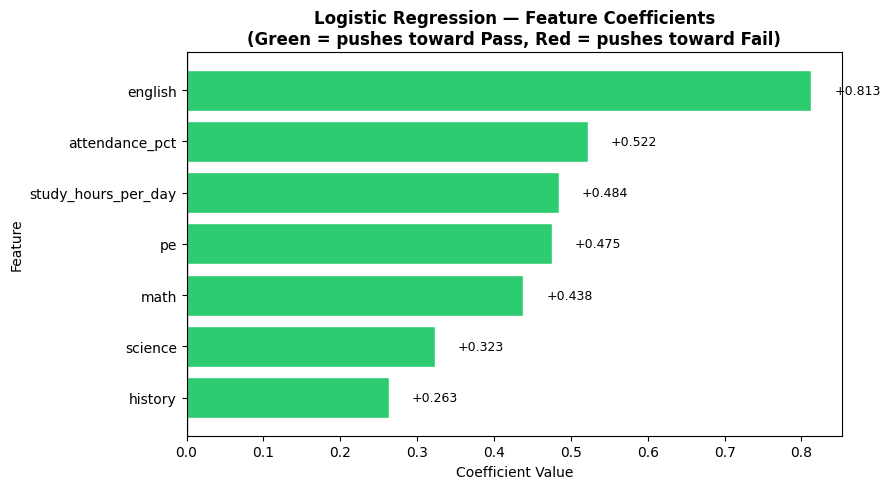

✅ plot8_coefficients.png saved


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ── Extract and display coefficients ──────────────────────────
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': coefficients
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False).reset_index(drop=True)

print("Feature Coefficients (sorted by importance):")
print("-" * 40)
for _, row in coef_df.iterrows():
    direction = '→ Push to Pass' if row['Coefficient'] > 0 else '→ Push to Fail'
    print(f"{row['Feature']:<25} {row['Coefficient']:+.4f}   {direction}")

# ── Horizontal bar chart ──────────────────────────────────────
coef_plot = coef_df.sort_values('Coefficient')  # sort low→high for chart
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_plot['Coefficient']]

plt.figure(figsize=(9, 5))
bars = plt.barh(coef_plot['Feature'], coef_plot['Coefficient'],
                color=colors, edgecolor='white')

# Zero reference line
plt.axvline(0, color='black', linewidth=0.9, linestyle='-')

# Value labels on each bar
for bar, val in zip(bars, coef_plot['Coefficient']):
    x_pos = val + 0.03 if val >= 0 else val - 0.03
    ha    = 'left'      if val >= 0 else 'right'
    plt.text(x_pos, bar.get_y() + bar.get_height() / 2,
             f'{val:+.3f}', va='center', ha=ha, fontsize=9)

plt.title('Logistic Regression — Feature Coefficients\n'
          '(Green = pushes toward Pass, Red = pushes toward Fail)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot8_coefficients.png')
plt.show()
print("✅ plot8_coefficients.png saved")

In [14]:
# ── Define new student ────────────────────────────────────────
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_cols)

# ── Scale and predict ─────────────────────────────────────────
new_student_scaled = scaler.transform(new_student)
prediction         = model.predict(new_student_scaled)[0]
probabilities      = model.predict_proba(new_student_scaled)[0]

# ── Display result ────────────────────────────────────────────
print("🎓 New Student Prediction")
print("-" * 35)
print(f"Input features : {dict(zip(feature_cols, new_student.values[0]))}")
print()
print(f"Prediction     : {'✅ PASS' if prediction == 1 else '❌ FAIL'}")
print(f"Pass probability: {probabilities[1]:.2%}")
print(f"Fail probability: {probabilities[0]:.2%}")

🎓 New Student Prediction
-----------------------------------
Input features : {'math': np.float64(75.0), 'science': np.float64(70.0), 'english': np.float64(68.0), 'history': np.float64(65.0), 'pe': np.float64(80.0), 'attendance_pct': np.float64(82.0), 'study_hours_per_day': np.float64(3.2)}

Prediction     : ✅ PASS
Pass probability: 90.80%
Fail probability: 9.20%
